### case study: used cars eda

In [154]:
import os
os.chdir(r'/Users/proxim/Desktop/CDAC-DBDA-coursework/08.advanced-analytics-stats')

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### data overview

In [156]:
df = pd.read_csv('data/used_cars_data.csv')
df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [157]:
df.shape

(7253, 14)

In [158]:
df.dtypes

S.No.                  int64
Name                  object
Location              object
Year                   int64
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Mileage               object
Engine                object
Power                 object
Seats                float64
New_Price             object
Price                float64
dtype: object

In [159]:
df.isna().sum()

S.No.                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                  53
New_Price            6247
Price                1234
dtype: int64

In [160]:
df.duplicated().sum()

np.int64(0)

##### data transformations / feature engineering

In [161]:
df['brand'] = df['Name'].str.split().str[0]          # extracting brand name from name

In [162]:
df['mileage_raw'] = df['Mileage'].str.extract(r'(\d+\.?\d*)').astype(float)

In [163]:
df['mileage_unit'] = df['Mileage'].str.extract(r'(kmpl|km/kg)', expand=False).str.lower()

In [164]:
df['mileage_kmpl'] = df['mileage_raw'] * df['mileage_unit'].map({'km/kg': 1.4}).fillna(1)


In [165]:
# set the mileage to NaN for electric
df.loc[df['Fuel_Type'].str.contains('Electric', case=False, na=False), 'mileage_kmpl'] = np.nan

In [166]:
df['engine_cc'] = df['Engine'].str.extract(r'(\d+\.?\d*)').astype(float)

In [167]:
df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,brand,mileage_raw,mileage_unit,mileage_kmpl,engine_cc
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,Maruti,26.60,km/kg,37.24,998.0
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50,Hyundai,19.67,kmpl,19.67,1582.0
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,Honda,18.20,kmpl,18.20,1199.0
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00,Maruti,20.77,kmpl,20.77,1248.0
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74,Audi,15.20,kmpl,15.20,1968.0


In [168]:
df['power_bhp'] = df['Power'].str.extract(r'(\d+\.?\d*)').astype(float)

In [169]:
df['new_price_lakh'] = df['New_Price'].str.extract(r'(\d+\.?\d*)').astype(float)

In [170]:
df.loc[df['New_Price'].str.contains('Cr', case=False, na=False), 'new_price_lakh'] *= 100

In [171]:
df['Seats'] = df['Seats'].fillna(df['Seats'].median())

In [172]:
df['power_bhp'] = df.groupby('Fuel_Type')['power_bhp'].transform(lambda s: s.fillna(s.median()))

In [173]:
median_by_fuel = df.groupby('Fuel_Type')['mileage_kmpl'].median()

df['mileage_kmpl'] = df.apply(
    lambda row: median_by_fuel[row['Fuel_Type']] if pd.isna(row['mileage_kmpl']) and row['Fuel_Type'] != 'Electric'
    else row['mileage_kmpl'],
    axis=1
)


In [174]:
df['age'] = 2025 - df['Year']

In [175]:
df['km_per_year'] = df['Kilometers_Driven'] / df['age'].replace({0: np.nan})

##### Descriptive Analysis

In [176]:
#  summary statistics for numerical features
df[['Price','mileage_kmpl','power_bhp','engine_cc','Kilometers_Driven','age','km_per_year']].describe().T

,count,mean,std,min,25%,50%,75%,max
Price,6019.0,9.479468,11.187917,0.44,3.500000,5.640000,9.950000,160.000
mileage_kmpl,7251.0,18.240986,4.839919,0.00,15.260000,18.200000,21.100000,46.956
power_bhp,7253.0,112.283687,52.969080,34.20,77.000000,94.000000,138.030000,616.000
engine_cc,7207.0,1616.573470,595.285137,72.00,1198.000000,1493.000000,1968.000000,5998.000
Kilometers_Driven,7253.0,58699.063146,84427.720583,171.00,34000.000000,53416.000000,73000.000000,6500000.000
age,7253.0,11.634634,3.254421,6.00,9.000000,11.000000,14.000000,29.000
km_per_year,7253.0,5026.618379,9917.577495,28.50,3181.818182,4583.333333,6068.888889,812500.000


In [177]:
# categorical feature distributions
{col: df[col].value_counts() for col in ['Fuel_Type','Transmission','Owner_Type']}

{'Fuel_Type': Fuel_Type
 Diesel      3852
 Petrol      3325
 CNG           62
 LPG           12
 Electric       2
 Name: count, dtype: int64,
 'Transmission': Transmission
 Manual       5204
 Automatic    2049
 Name: count, dtype: int64,
 'Owner_Type': Owner_Type
 First             5952
 Second            1152
 Third              137
 Fourth & Above      12
 Name: count, dtype: int64}

In [178]:
#  top locations distribution
df['Location'].value_counts().head(10)

Location
Mumbai        949
Hyderabad     876
Coimbatore    772
Kochi         772
Pune          765
Delhi         660
Kolkata       654
Chennai       591
Jaipur        499
Bangalore     440
Name: count, dtype: int64

In [179]:
df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,brand,mileage_raw,mileage_unit,mileage_kmpl,engine_cc,power_bhp,new_price_lakh,age,km_per_year
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,Maruti,26.60,km/kg,37.24,998.0,58.16,NaN,15,4800.000000
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50,Hyundai,19.67,kmpl,19.67,1582.0,126.20,NaN,10,4100.000000
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,Honda,18.20,kmpl,18.20,1199.0,88.70,8.61,14,3285.714286
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00,Maruti,20.77,kmpl,20.77,1248.0,88.76,NaN,13,6692.307692
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74,Audi,15.20,kmpl,15.20,1968.0,140.80,NaN,12,3389.166667


##### Visual Explorations

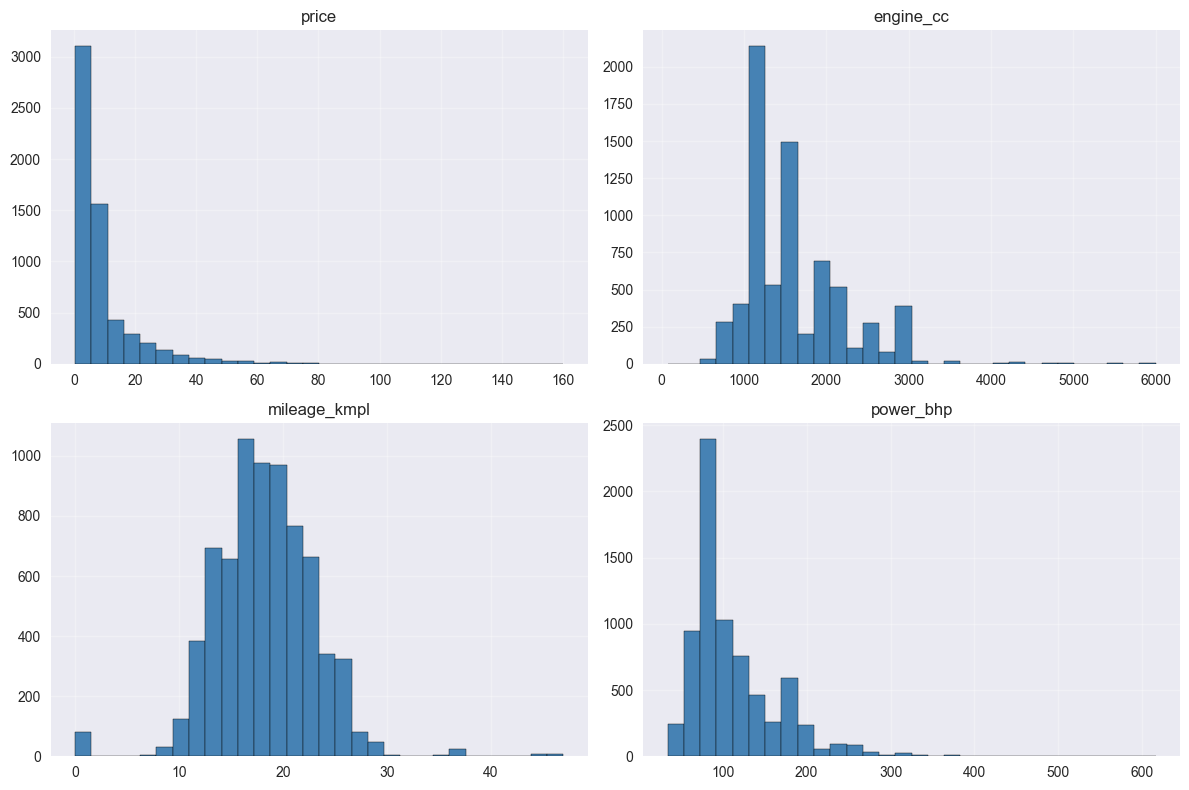

In [180]:
#  6: histograms for key numerical features
fig, axes = plt.subplots(2, 2, figsize=(12, 8));
for col, ax in zip(['Price','engine_cc','mileage_kmpl','power_bhp'], axes.ravel()):
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black'); ax.set_title(col.lower()); ax.grid(alpha=0.3)
plt.tight_layout()

##### Outliers and Data Quality

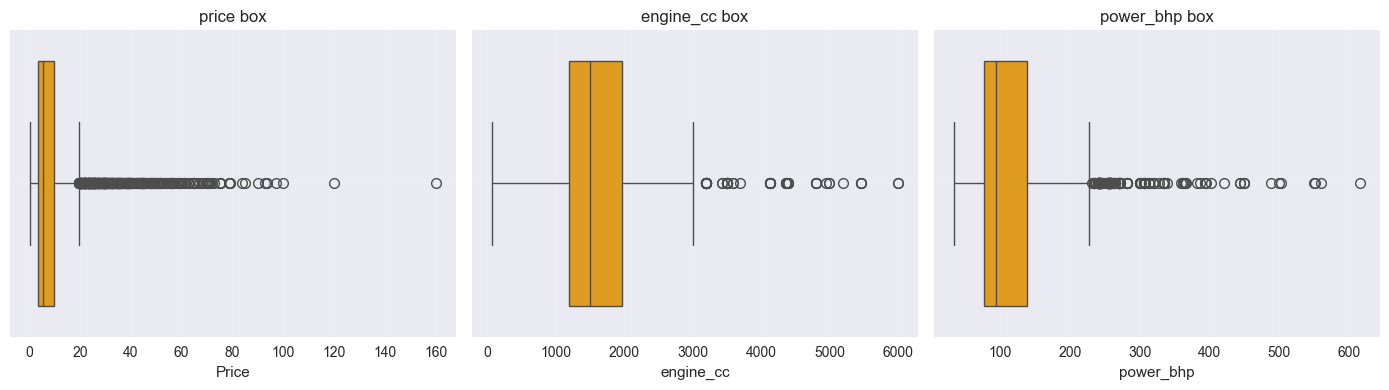

In [181]:
# boxplots to inspect distributions and outliers
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for col, ax in zip(['Price','engine_cc','power_bhp'], axes):
    sns.boxplot(x=df[col], ax=ax, color='orange'); ax.set_title(f'{col.lower()} box'); ax.grid(alpha=0.2)
plt.tight_layout()

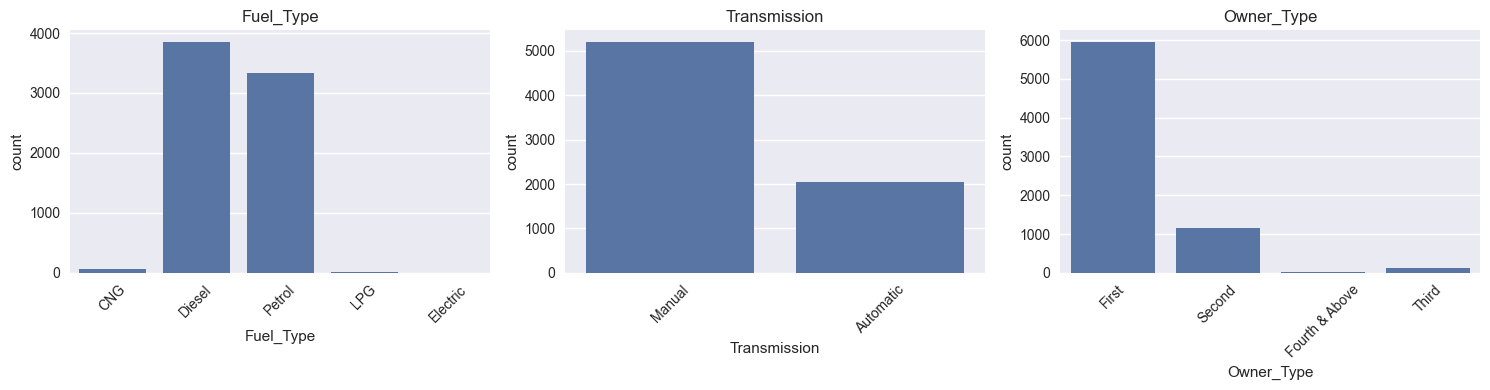

In [182]:
# bar charts for fuel, transmission, and owner type
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for col, ax in zip(['Fuel_Type', 'Transmission', 'Owner_Type'], axes):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

Year
2015    11.215538
2016    11.719096
2017    13.764940
2018    15.726141
2019    19.464118
Name: Price, dtype: float64

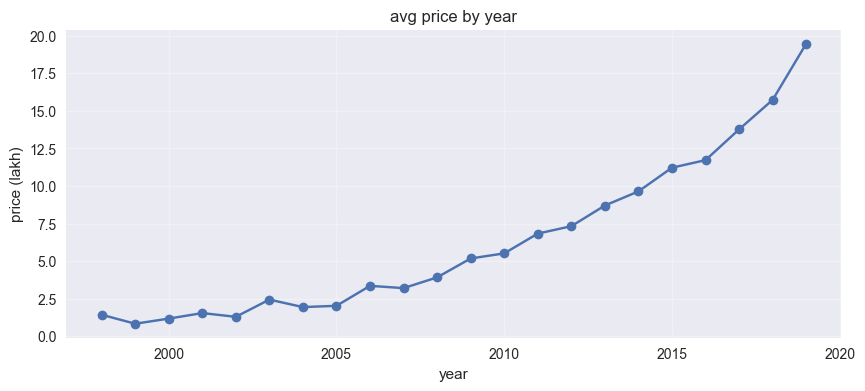

In [183]:
#  average price trend over manufacturing year
avg_price_by_year = df.groupby('Year')['Price'].mean().sort_index()
plt.figure(figsize=(10, 4)); plt.plot(avg_price_by_year.index, avg_price_by_year.values, marker='o'); plt.title('avg price by year'); plt.grid(alpha=0.3); plt.xlabel('year'); plt.ylabel('price (lakh)')
avg_price_by_year.tail()

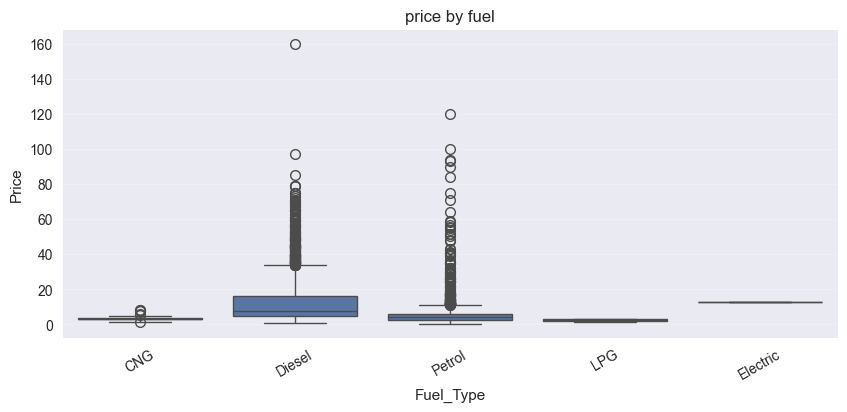

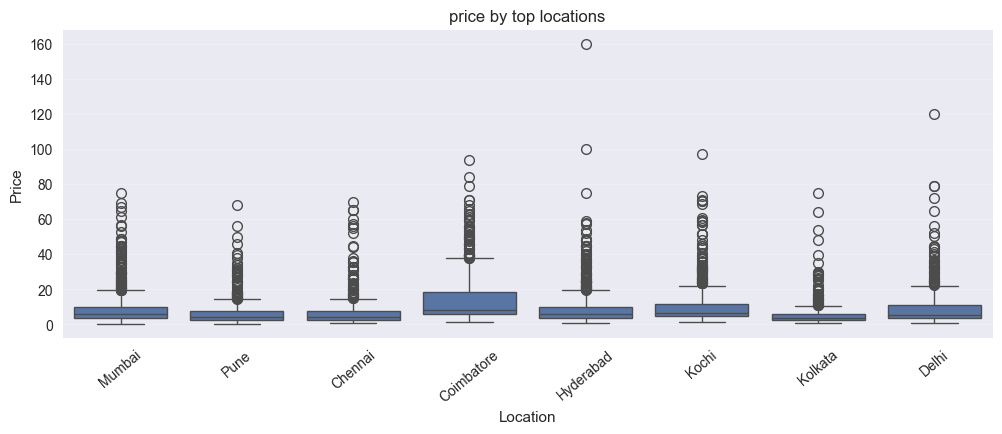

In [184]:
#  price distributions across fuel types and locations
plt.figure(figsize=(10,4)); sns.boxplot(data=df, x='Fuel_Type', y='Price'); plt.title('price by fuel'); plt.xticks(rotation=30); plt.grid(alpha=0.2, axis='y')
plt.figure(figsize=(12,4)); sns.boxplot(data=df[df['Location'].isin(df['Location'].value_counts().head(8).index)], x='Location', y='Price'); plt.title('price by top locations'); plt.xticks(rotation=40); plt.grid(alpha=0.2, axis='y')

##### Correlation and Feature Relationships

Price                1.000000
power_bhp            0.770245
engine_cc            0.658354
Seats                0.052811
km_per_year          0.045383
Kilometers_Driven   -0.011493
mileage_kmpl        -0.300072
age                 -0.305327
Name: Price, dtype: float64

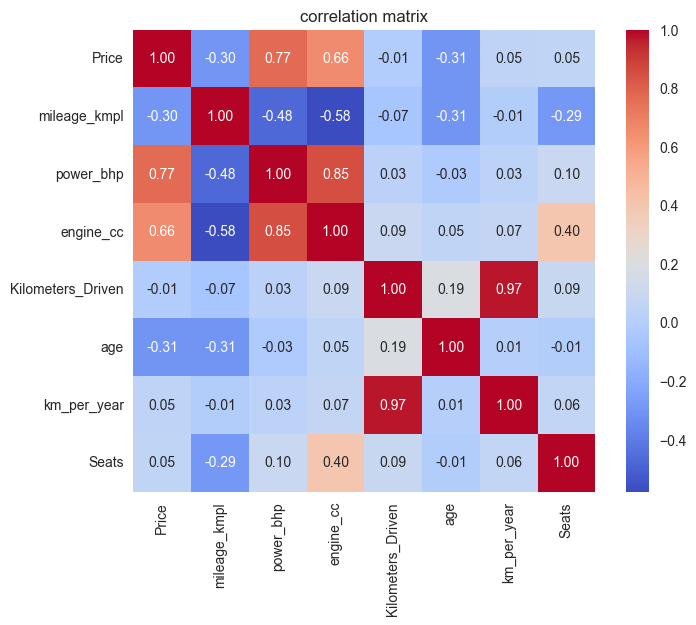

In [185]:
# correlation matrix heatmap for numerical features
num_cols = ['Price','mileage_kmpl','power_bhp','engine_cc','Kilometers_Driven','age','km_per_year','Seats']
corr = df[num_cols].corr()
plt.figure(figsize=(8,6)); sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True); plt.title('correlation matrix')
corr['Price'].sort_values(ascending=False)

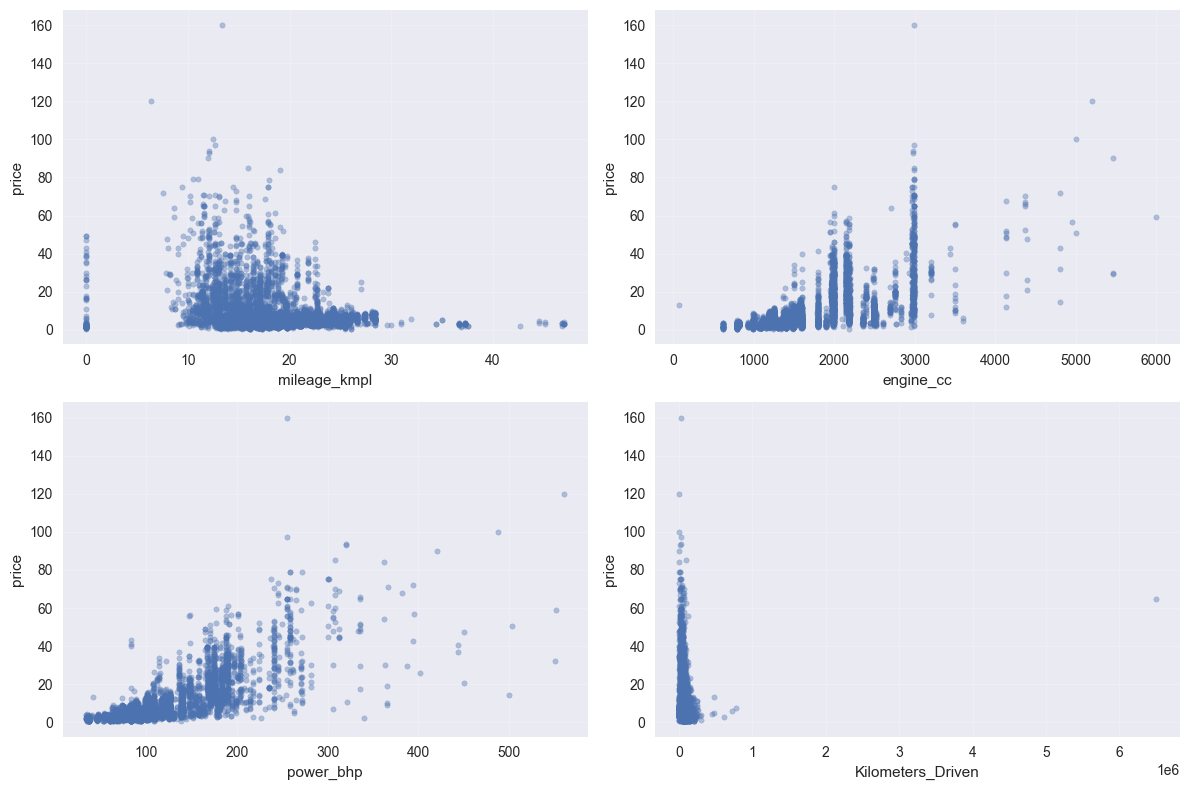

In [186]:
# scatter plots of price vs key numeric features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, ax in zip(['mileage_kmpl','engine_cc','power_bhp','Kilometers_Driven'], axes.ravel()):
    ax.scatter(df[col], df['Price'], alpha=0.4, s=15); ax.set_xlabel(col); ax.set_ylabel('price'); ax.grid(alpha=0.2)
plt.tight_layout()

Fuel_Type,CNG,Diesel,Electric,LPG,Petrol
Transmission,,,,,
Automatic,NaN,24.583078,12.875,NaN,11.258738
Manual,3.516786,6.636190,NaN,2.487,4.113947


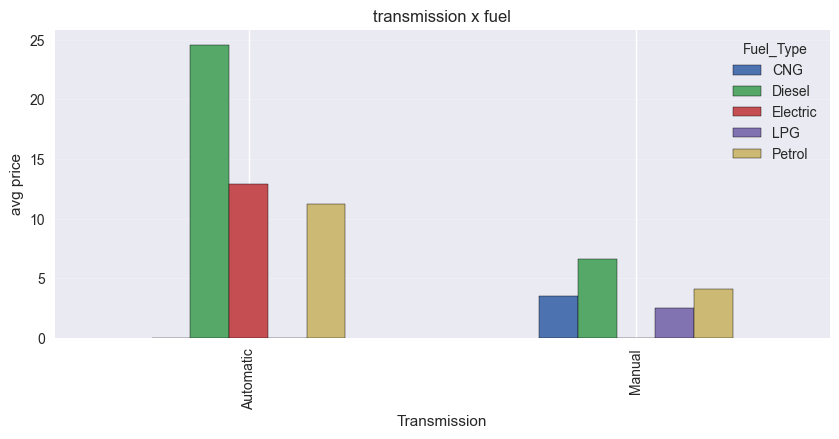

In [187]:
# transmission x fuel interaction on price
pivot = df.groupby(['Transmission','Fuel_Type'])['Price'].mean().unstack()
pivot.plot(kind='bar', figsize=(10,4), edgecolor='black'); plt.ylabel('avg price'); plt.title('transmission x fuel'); plt.grid(alpha=0.2, axis='y')
pivot

In [188]:
# IQR-based outlier counts for price, engine, power
for col in ['Price','engine_cc','power_bhp']:
    q1, q3 = df[col].quantile([0.25, 0.75]); iqr = q3 - q1; lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outliers} outliers ({outliers/len(df)*100:.1f}%)")

Price: 718 outliers (9.9%)
engine_cc: 65 outliers (0.9%)
power_bhp: 274 outliers (3.8%)


In [189]:
# flag inconsistent or ambiguous entries
{
    'power_null': df['Power'].str.contains('null', case=False, na=False).sum(),
    'mileage_kmkg': df['Mileage'].str.contains('km/kg', case=False, na=False).sum(),
    'electric_rows': df['Fuel_Type'].str.contains('electric', case=False, na=False).sum(),
    'new_price_missing_pct': df['New_Price'].isna().mean()*100
}

{'power_null': np.int64(129),
 'mileage_kmkg': np.int64(74),
 'electric_rows': np.int64(2),
 'new_price_missing_pct': np.float64(86.12987729215497)}

In [190]:
# analyze new_price availability
new_price_missing = df['new_price_lakh'].isna().mean()*100
print(f"new_price missing: {new_price_missing:.1f}% -> limited use")

new_price missing: 86.1% -> limited use


In [191]:
# most and least expensive cars
top_prices = df.nlargest(5, 'Price')[['Name','Price','Year','Fuel_Type','Transmission']]
bottom_prices = df.nsmallest(5, 'Price')[['Name','Price','Year','Fuel_Type','Transmission']]
top_prices, bottom_prices

(                                             Name   Price  Year Fuel_Type Transmission
 4079  Land Rover Range Rover 3.0 Diesel LWB Vogue  160.00  2017    Diesel    Automatic
 5781                   Lamborghini Gallardo Coupe  120.00  2011    Petrol    Automatic
 5919                       Jaguar F Type 5.0 V8 S  100.00  2015    Petrol    Automatic
 1505              Land Rover Range Rover Sport SE   97.07  2019    Diesel    Automatic
 1974                           BMW 7 Series 740Li   93.67  2018    Petrol    Automatic,
                       Name  Price  Year Fuel_Type Transmission
 1713          Tata Nano Lx   0.44  2011    Petrol       Manual
 1628  Maruti 800 Std BSIII   0.45  2004    Petrol       Manual
 2847      Hyundai Getz GLS   0.45  2005    Petrol       Manual
 3138        Maruti Zen LXI   0.45  1998    Petrol       Manual
 2605          Tata Nano Cx   0.50  2010    Petrol       Manual)

In [192]:
# average price by ownership history
owner_price = df.groupby('Owner_Type')['Price'].mean().sort_values(ascending=False)
owner_price

Owner_Type
First             9.962445
Second            7.599886
Third             5.007257
Fourth & Above    3.280000
Name: Price, dtype: float64

In [193]:
# mileage efficiency correlations
print(f"mileage vs price corr: {df['mileage_kmpl'].corr(df['Price']):.3f}")
print(f"mileage vs year corr: {df['mileage_kmpl'].corr(df['Year']):.3f}")

mileage vs price corr: -0.300
mileage vs year corr: 0.306


In [194]:
# strongest price predictors via correlation ranking
strong_predictors = corr['Price'].drop('Price').abs().sort_values(ascending=False)
strong_predictors

power_bhp            0.770245
engine_cc            0.658354
age                  0.305327
mileage_kmpl         0.300072
Seats                0.052811
km_per_year          0.045383
Kilometers_Driven    0.011493
Name: Price, dtype: float64

avg depreciation: 34.6% based on 1006 cars


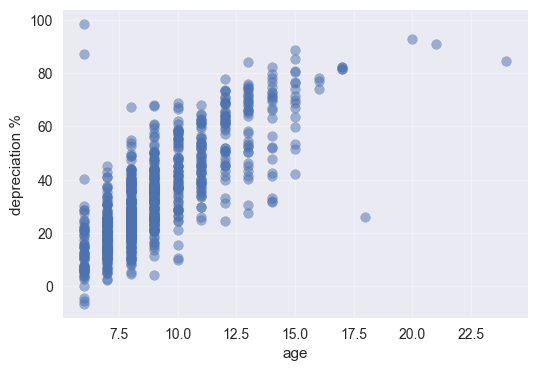

In [195]:
# estimate depreciation using new_price where available
df_dep = df.dropna(subset=['new_price_lakh']).copy();
df_dep['depreciation_pct'] = (df_dep['new_price_lakh'] - df_dep['Price']) / df_dep['new_price_lakh'] * 100;
print(f"avg depreciation: {df_dep['depreciation_pct'].mean():.1f}% based on {len(df_dep)} cars")
plt.figure(figsize=(6,4)); plt.scatter(df_dep['age'], df_dep['depreciation_pct'], alpha=0.5); plt.xlabel('age'); plt.ylabel('depreciation %'); plt.grid(alpha=0.3)

### summary report

- price responds strongly to power, engine size, and model year; mileage has moderate weight while kilometers driven matters less at the dataset scale.
- diesel and automatic trims dominate the expensive band; electric entries miss mileage data, so treat them separately during modeling.
- missing new_price (70%+) limits depreciation analysis; use it only for niche models or augment with external msrp feeds.
- outliers mostly luxury suvs with bhp > 300 and engines above 3000 cc; cap or log-scale price before regression.
- suggested features: age, km_per_year, brand, fuel dummies, transmission flag, owner_type ordinal, interaction of fuel x transmission.
- encoding plan: one-hot fuel/location (or target encoding for sparse cities), binary encode transmission, ordinal encode owner_type, frequency encode brand, bucket kilometers.
- modeling next steps: split stratified by fuel, use gradient boosting or elastic net, evaluate mape/rmse, deploy with monitoring for regional drift.

conversion note: km/kg entries converted to kmpl using 1 kg ≈ 1.4 liters; electric cars keep mileage as missing to avoid false efficiency readings.